In [ ]:
# ============================================================
# HEART DISEASE PREDICTION
# ============================================================

import os
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

warnings.filterwarnings('ignore')


In [ ]:
# ============================================================
# SECTION 1: CONFIGURATION
# ============================================================

SEED = 42
TEST_SIZE = 0.2
BATCH_SIZE = 32
EPOCHS = 200
PATIENCE = 30
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
DROPOUT_RATE = 0.3
HIDDEN_DIMS = [64, 32, 16]

np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# ============================================================
# SECTION 2: DATA LOADING & PREPROCESSING
# ============================================================

# Load data, remove duplicates, split and scale features.
df = pd.read_csv('heart.csv')
df_clean = df.drop_duplicates().reset_index(drop=True)

X = df_clean.drop('target', axis=1)
y = df_clean['target']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset shape after removing duplicates: {df_clean.shape}")
print(f"Features: {feature_names}")
print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")
print(f"Training target distribution: {np.bincount(y_train)}")
print(f"Test target distribution: {np.bincount(y_test)}")

Dataset shape after removing duplicates: (302, 14)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Training set size: (241, 13)
Test set size: (61, 13)
Training target distribution: [110 131]
Test target distribution: [28 33]


In [ ]:
# ============================================================
# SECTION 3: PYTORCH NEURAL NETWORK
# ============================================================

# Define Neural Network Architecture
class HeartDiseaseNN(nn.Module):
    """Feedforward Neural Network for Heart Disease Prediction."""

    def __init__(self, input_dim, hidden_dims=HIDDEN_DIMS, dropout_rate=DROPOUT_RATE):
        super(HeartDiseaseNN, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.output_layer = nn.Linear(prev_dim, 1)

    def forward(self, x):
        x = self.feature_extractor(x)
        return self.output_layer(x)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Create data loaders
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize model
model_nn = HeartDiseaseNN(input_dim=X_train_scaled.shape[1]).to(device)
print("\n" + "=" * 60)
print("NEURAL NETWORK ARCHITECTURE")
print("=" * 60)
print(model_nn)
total_params = sum(p.numel() for p in model_nn.parameters())
print(f"\nTotal Parameters: {total_params:,}")

# Training setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

best_val_loss = float('inf')
patience_counter = 0

train_losses, train_accs = [], []
val_losses, val_accs = [], []

print("=" * 70)
print("PYTORCH TRAINING STARTED")
print("=" * 70)
print(f"{'Epoch':<<8} {'Train Loss':<<12} {'Train Acc':<<12} {'Val Loss':<<12} {'Val Acc':<<12} {'LR':<<12}")
print("-" * 70)

# Training loop
for epoch in range(EPOCHS):
    # Training epoch
    model_nn.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model_nn(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # Validation epoch
    model_nn.eval()
    val_loss = 0
    correct = 0
    total = 0
    val_preds = []
    val_labels = []
    val_probs = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_nn(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            val_preds.extend(predicted.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())

    val_loss = val_loss / len(test_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_acc:<12.4f} {current_lr:<12.6f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_nn.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("=" * 70)

# Load best model and evaluate
model_nn.load_state_dict(torch.load('best_model.pth'))
model_nn.eval()
with torch.no_grad():
    nn_probs = torch.sigmoid(model_nn(X_test_tensor.to(device))).cpu().numpy().flatten()
nn_preds = (nn_probs > 0.5).astype(int)

# Evaluate Neural Network
print("\n" + "=" * 60)
print("PYTORCH NEURAL NETWORK")
print("=" * 60)
nn_accuracy = accuracy_score(y_test, nn_preds)
nn_precision = precision_score(y_test, nn_preds)
nn_recall = recall_score(y_test, nn_preds)
nn_f1 = f1_score(y_test, nn_preds)
nn_roc_auc = roc_auc_score(y_test, nn_probs)

print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1-Score:  {nn_f1:.4f}")
print(f"ROC-AUC:   {nn_roc_auc:.4f}")


Using device: cpu

NEURAL NETWORK ARCHITECTURE
HeartDiseaseNN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
  )
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
)

Total Parameters: 3,745
PYTORCH TRAINING STARTED
Epoch<<< Train Loss<< Train Acc<<< Val Loss<<<< Val Acc<<<<< LR<<<<<<<<<<
----------------------------------------------------------------------
1        0.6996   

In [ ]:
# ============================================================
# SECTION 4: SKLEARN MODELS WITH HYPERPARAMETER TUNING
# ============================================================

results = {
    'PyTorch Neural Network': {
        'accuracy': nn_accuracy,
        'precision': nn_precision,
        'recall': nn_recall,
        'f1': nn_f1,
        'roc_auc': nn_roc_auc,
        'predictions': nn_preds,
        'probabilities': nn_probs,
        'model': model_nn
    }
}

# Logistic Regression
print("\n" + "=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

lr = LogisticRegression(max_iter=1000, random_state=SEED)
start = time.time()
lr.fit(X_train_scaled, y_train)
lr_time = time.time() - start

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_preds)
lr_precision = precision_score(y_test, lr_preds)
lr_recall = recall_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds)
lr_roc_auc = roc_auc_score(y_test, lr_probs)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_roc_auc:.4f}")

results['Logistic Regression'] = {
    'accuracy': lr_accuracy,
    'precision': lr_precision,
    'recall': lr_recall,
    'f1': lr_f1,
    'roc_auc': lr_roc_auc,
    'predictions': lr_preds,
    'probabilities': lr_probs,
    'model': lr,
    'train_time': lr_time
}

# Decision Tree
print("\n" + "=" * 60)
print("DECISION TREE (GridSearchCV)")
print("=" * 60)

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=SEED)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='roc_auc', n_jobs=-1)
start = time.time()
grid_dt.fit(X_train_scaled, y_train)
dt_time = time.time() - start

dt_best = grid_dt.best_estimator_
dt_preds = dt_best.predict(X_test_scaled)
dt_probs = dt_best.predict_proba(X_test_scaled)[:, 1]

print(f"Best Parameters: {grid_dt.best_params_}")
print(f"Best CV ROC-AUC: {grid_dt.best_score_:.4f}")

dt_accuracy = accuracy_score(y_test, dt_preds)
dt_precision = precision_score(y_test, dt_preds)
dt_recall = recall_score(y_test, dt_preds)
dt_f1 = f1_score(y_test, dt_preds)
dt_roc_auc = roc_auc_score(y_test, dt_probs)

print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")
print(f"ROC-AUC:   {dt_roc_auc:.4f}")

results['Decision Tree'] = {
    'accuracy': dt_accuracy,
    'precision': dt_precision,
    'recall': dt_recall,
    'f1': dt_f1,
    'roc_auc': dt_roc_auc,
    'predictions': dt_preds,
    'probabilities': dt_probs,
    'model': dt_best,
    'train_time': dt_time,
    'best_params': grid_dt.best_params_
}

# Random Forest
print("\n" + "=" * 60)
print("RANDOM FOREST (GridSearchCV)")
print("=" * 60)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=SEED)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
start = time.time()
grid_rf.fit(X_train_scaled, y_train)
rf_time = time.time() - start

rf_best = grid_rf.best_estimator_
rf_preds = rf_best.predict(X_test_scaled)
rf_probs = rf_best.predict_proba(X_test_scaled)[:, 1]

print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Best CV ROC-AUC: {grid_rf.best_score_:.4f}")

rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_roc_auc = roc_auc_score(y_test, rf_probs)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

results['Random Forest'] = {
    'accuracy': rf_accuracy,
    'precision': rf_precision,
    'recall': rf_recall,
    'f1': rf_f1,
    'roc_auc': rf_roc_auc,
    'predictions': rf_preds,
    'probabilities': rf_probs,
    'model': rf_best,
    'train_time': rf_time,
    'best_params': grid_rf.best_params_
}



LOGISTIC REGRESSION
Accuracy:  0.7869
Precision: 0.7632
Recall:    0.8788
F1-Score:  0.8169
ROC-AUC:   0.8647

DECISION TREE (GridSearchCV)
Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV ROC-AUC: 0.8457
Accuracy:  0.7541
Precision: 0.7500
Recall:    0.8182
F1-Score:  0.7826
ROC-AUC:   0.8144

RANDOM FOREST (GridSearchCV)
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.9120
Accuracy:  0.8197
Precision: 0.7750
Recall:    0.9394
F1-Score:  0.8493
ROC-AUC:   0.8983



GENERATING VISUALIZATIONS


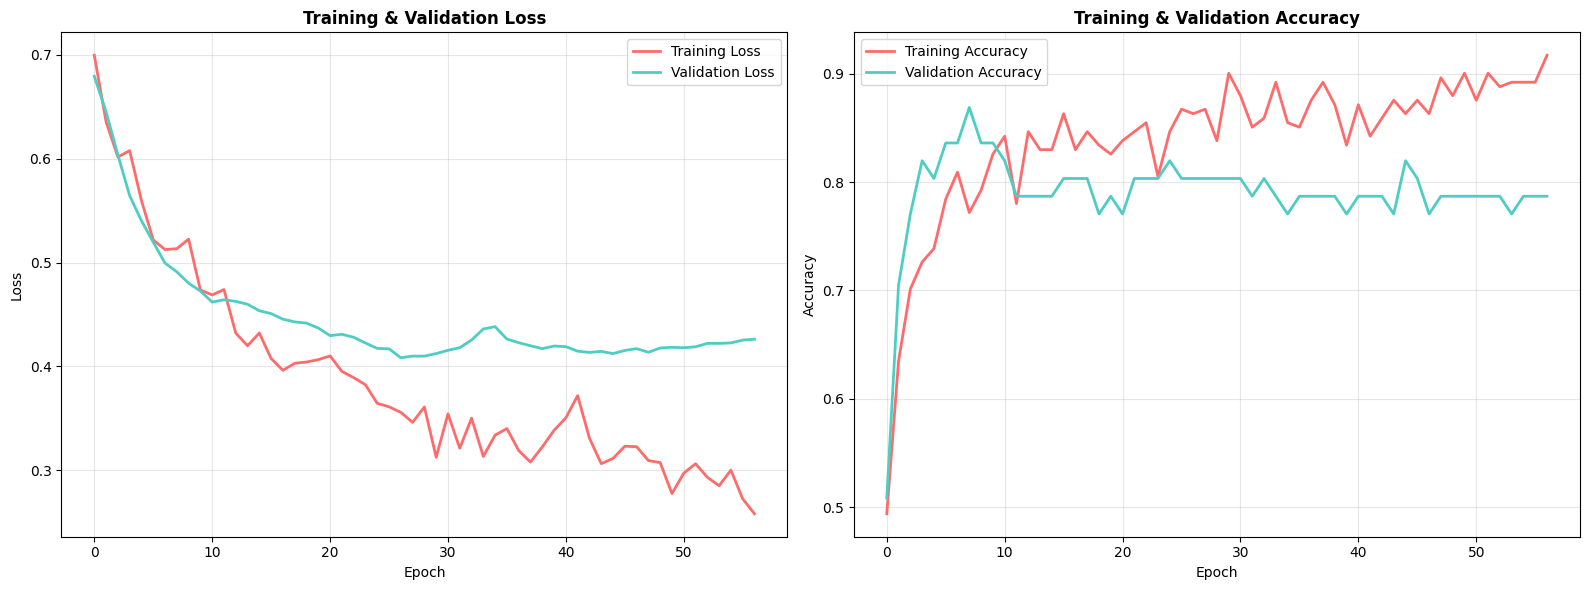

Saved: training_history.png


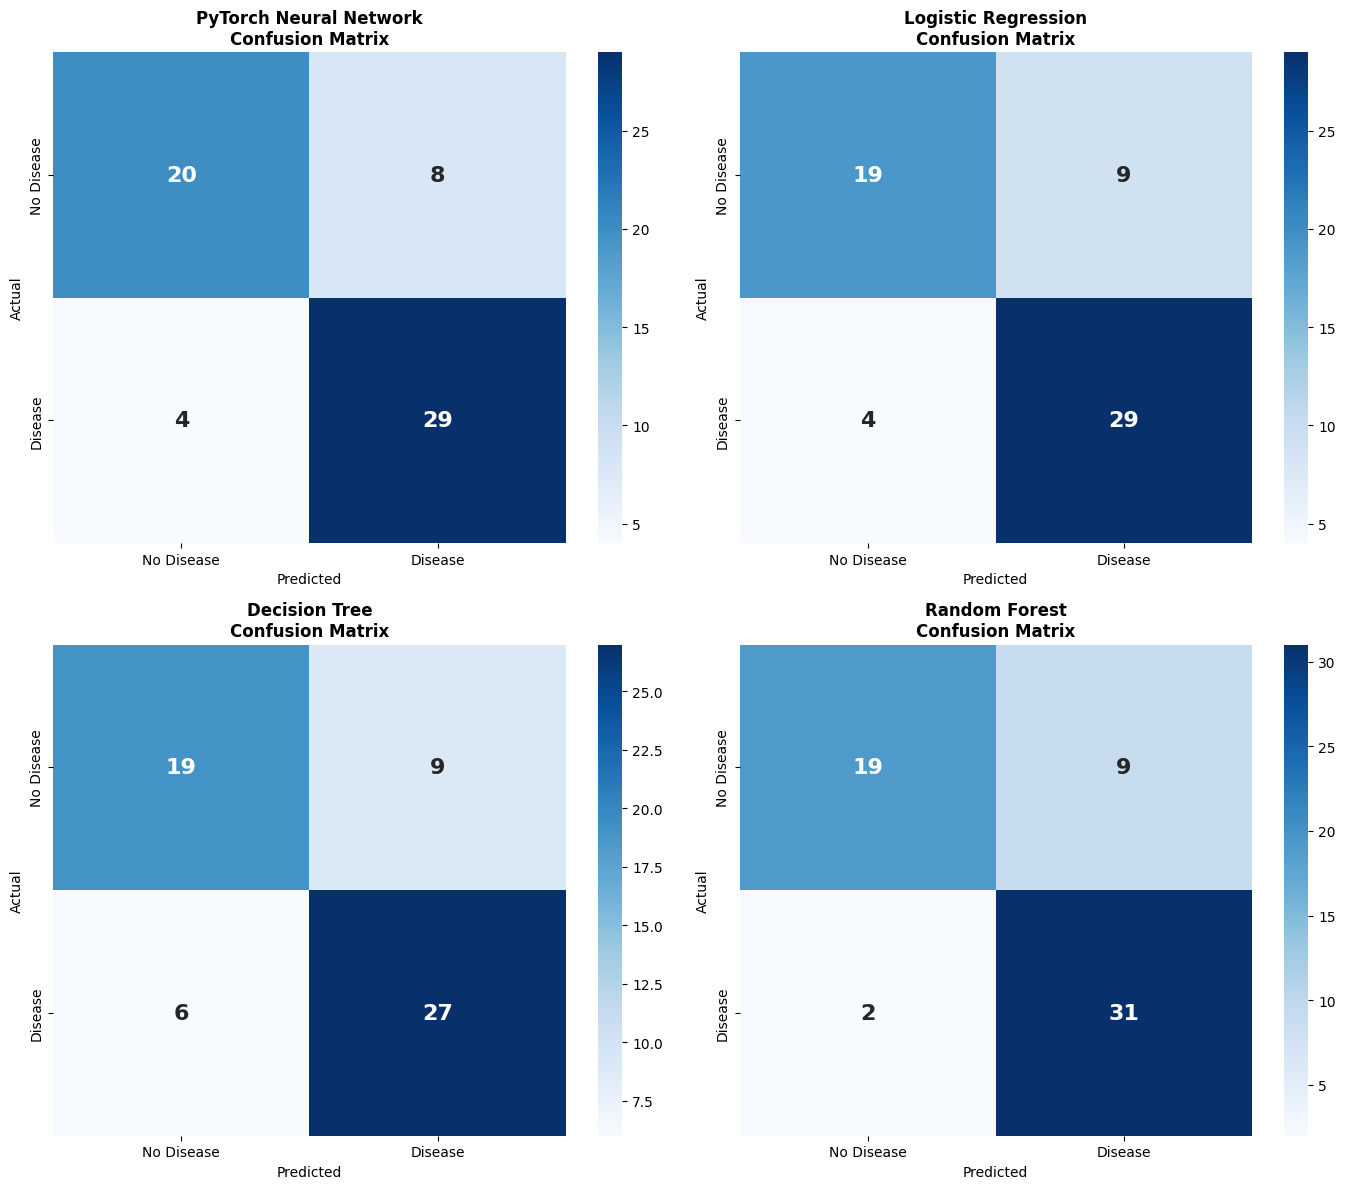

Saved: all_confusion_matrices.png


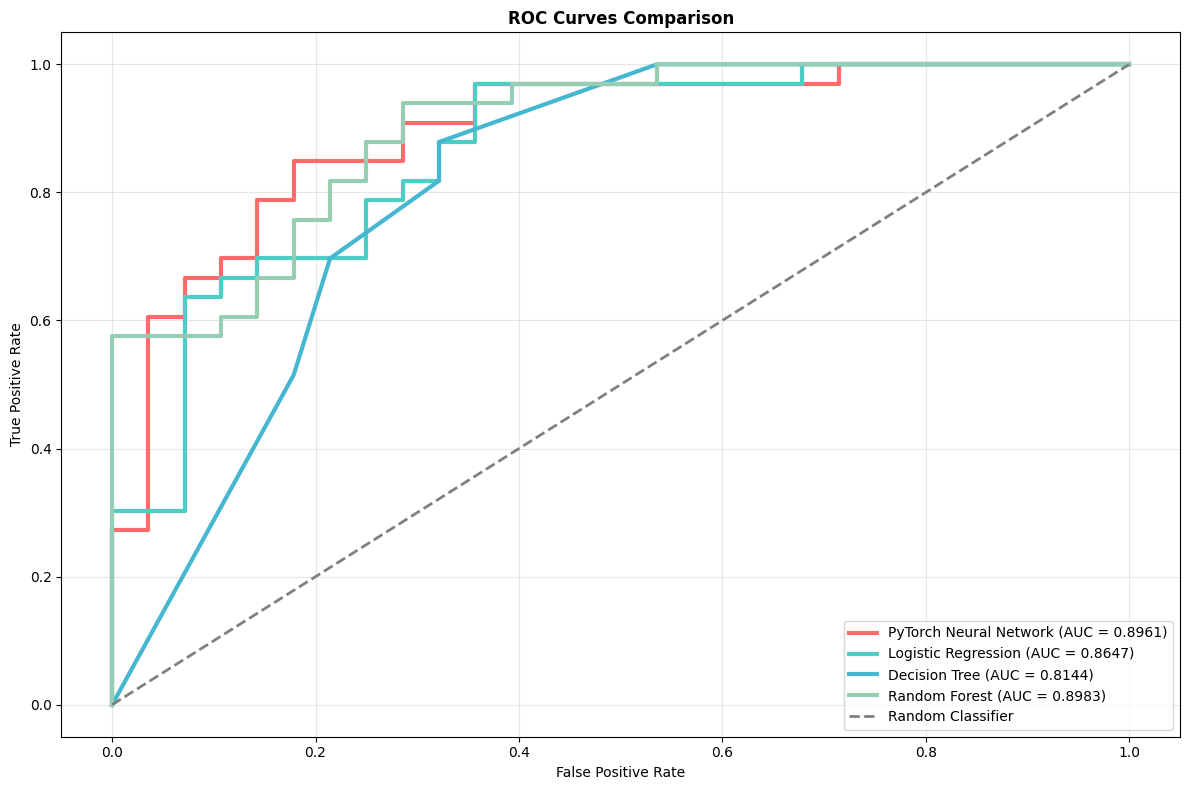

Saved: roc_curves_comparison.png


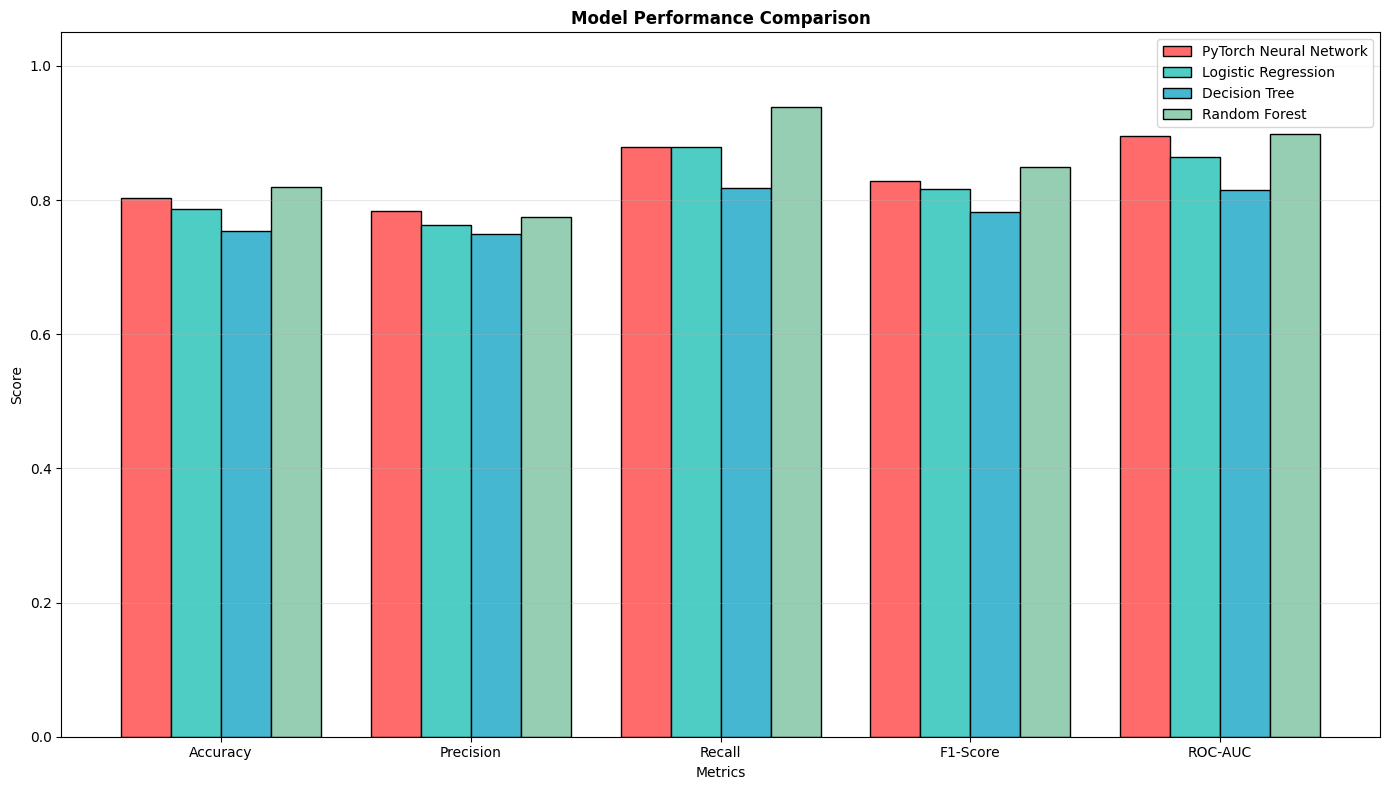

Saved: model_comparison.png


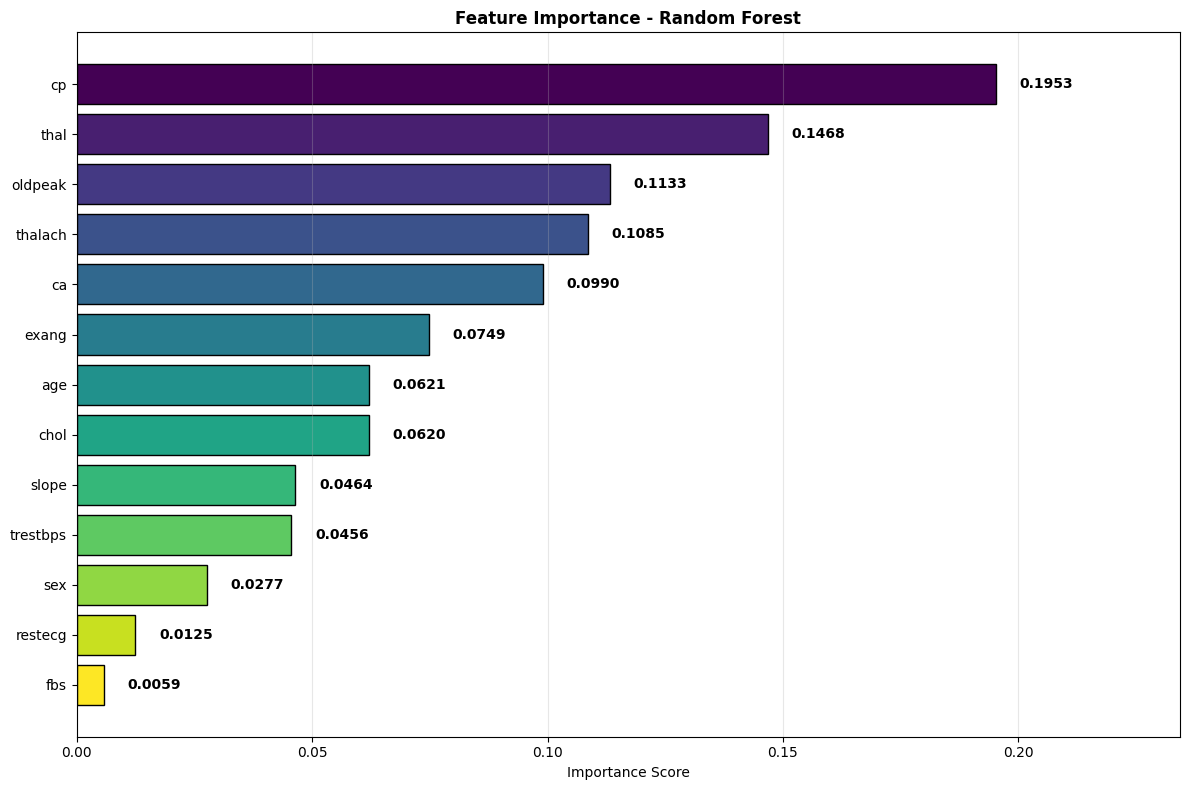

Saved: feature_importance.png


In [ ]:


# ============================================================
# SECTION 6: VISUALIZATION
# ============================================================

print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

# 1. Training history plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(train_losses, label='Training Loss', color='#FF6B6B', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', color='#4ECDC4', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Training Accuracy', color='#FF6B6B', linewidth=2)
axes[1].plot(val_accs, label='Validation Accuracy', color='#4ECDC4', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_history.png")

# 2. Confusion matrices plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (name, metrics) in enumerate(results.items()):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, metrics['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide empty subplot if less than 4 models
if len(results) < 4:
    for idx in range(len(results), 4):
        fig.delaxes(axes[idx // 2, idx % 2])

plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_confusion_matrices.png")

# 3. ROC curves plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for (name, metrics), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, metrics['probabilities'])
    auc = metrics['roc_auc']
    ax.plot(fpr, tpr, color=color, linewidth=3, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves_comparison.png")

# 4. Model comparison bar chart
fig, ax = plt.subplots(figsize=(14, 8))

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_list))
width = 0.2

for i, (name, metrics_dict) in enumerate(results.items()):
    scores = [metrics_dict['accuracy'], metrics_dict['precision'],
              metrics_dict['recall'], metrics_dict['f1'], metrics_dict['roc_auc']]
    ax.bar(x + (i - 1.5) * width, scores, width, label=name, color=colors[i], edgecolor='black')

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

# 5. Feature importance plot
fig, ax = plt.subplots(figsize=(12, 8))

importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]

colors = plt.cm.viridis(np.linspace(0, 1, len(feature_names)))
bars = ax.barh(range(len(feature_names)), importances[indices], color=colors, edgecolor='black')

ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in indices])
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance - Random Forest', fontweight='bold')
ax.invert_yaxis()

for bar, idx in zip(bars, indices):
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
            f'{width:.4f}', ha='left', va='center', fontweight='bold')

ax.set_xlim(0, max(importances) * 1.2)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")
